# Baseline CNN 2D — Classificação exploratória de CT hepática

Este notebook apresenta os resultados do primeiro baseline CNN 2D para classificação binária das imagens JPEG de CT hepática:

- Healthy
- Hepatic_Steatosis

A lógica de treino e avaliação está implementada em scripts e módulos reutilizáveis do projeto. Este notebook funciona como relatório executável para leitura, visualização e discussão dos resultados com o grupo.

## Pontos metodológicos importantes

- O split foi feito por `inferred_group_id`, não por imagem individual.
- O conjunto de teste foi usado apenas na avaliação final.
- As imagens são JPEG, sem DICOM, NIfTI ou metadados clínicos.
- As métricas são avaliadas em dois níveis: slice e grupo inferido.
- As probabilidades dos slices são agregadas por média para obter a predição por grupo.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

REPORTS_DIR = PROJECT_ROOT / "reports" / "tables"

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print(f"Project root: {PROJECT_ROOT}")
print(f"Reports dir: {REPORTS_DIR}")

Project root: c:\GitHub\mestrado_ml_visao_computacional
Reports dir: c:\GitHub\mestrado_ml_visao_computacional\reports\tables


## 1. Carregamento das saídas geradas pelos scripts

Os arquivos abaixo foram gerados pelos scripts de treino e avaliação:

- `python scripts/train_baseline_cnn.py`
- `python scripts/evaluate_baseline_cnn.py`

Este notebook não recria splits e não treina novamente o modelo por padrão. Ele lê os resultados já salvos localmente.

In [2]:
required_files = {
    "training_history": REPORTS_DIR / "baseline_cnn_training_history.csv",
    "validation_metrics": REPORTS_DIR / "baseline_cnn_validation_metrics.csv",
    "test_metrics": REPORTS_DIR / "baseline_cnn_test_metrics.csv",
    "comparison": REPORTS_DIR / "baseline_cnn_vs_statistical_baseline_test.csv",
    "test_slice_predictions": REPORTS_DIR / "baseline_cnn_test_slice_predictions.csv",
    "test_group_predictions": REPORTS_DIR / "baseline_cnn_test_group_predictions.csv",
}

missing_files = [str(path) for path in required_files.values() if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Arquivos não encontrados. Rode antes os scripts de treino e avaliação:\n"
        "python scripts/train_baseline_cnn.py\n"
        "python scripts/evaluate_baseline_cnn.py\n\n"
        + "\n".join(missing_files)
    )

training_history = pd.read_csv(required_files["training_history"])
validation_metrics = pd.read_csv(required_files["validation_metrics"])
test_metrics = pd.read_csv(required_files["test_metrics"])
comparison = pd.read_csv(required_files["comparison"])
test_slice_predictions = pd.read_csv(required_files["test_slice_predictions"])
test_group_predictions = pd.read_csv(required_files["test_group_predictions"])

print("Arquivos carregados com sucesso.")

Arquivos carregados com sucesso.


## 2. Histórico de treinamento

A curva abaixo mostra a evolução da loss no treino e na validação.

O objetivo aqui não é maximizar performance a qualquer custo, mas verificar se a CNN pequena consegue aprender um sinal visual acima dos baselines simples.

,epoch,train_loss,val_loss,best_val_loss,improved
0,1,0.505721,0.441219,0.441219,1
1,2,0.445167,0.415104,0.415104,1
2,3,0.406699,0.349989,0.349989,1
3,4,0.378122,0.343473,0.343473,1
4,5,0.370392,0.696722,0.343473,0
5,6,0.342607,0.865803,0.343473,0
6,7,0.346863,0.792628,0.343473,0
7,8,0.334352,0.520763,0.343473,0
8,9,0.342139,0.293638,0.293638,1
9,10,0.309884,0.307698,0.293638,0


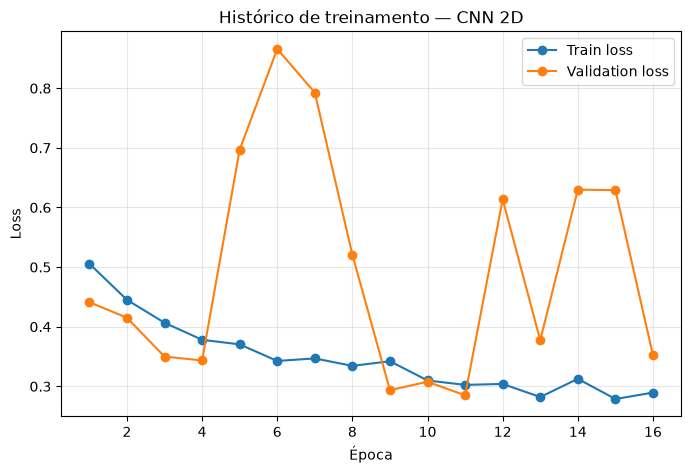

In [3]:
display(training_history)

plt.figure(figsize=(8, 5))

if "epoch" in training_history.columns:
    x = training_history["epoch"]
else:
    x = range(1, len(training_history) + 1)

if "train_loss" in training_history.columns:
    plt.plot(x, training_history["train_loss"], marker="o", label="Train loss")

if "val_loss" in training_history.columns:
    plt.plot(x, training_history["val_loss"], marker="o", label="Validation loss")

plt.title("Histórico de treinamento — CNN 2D")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. Métricas de validação

A validação foi usada para early stopping e seleção do checkpoint.

As métricas são apresentadas por slice e por grupo inferido.

In [4]:
metric_columns = [
    "model",
    "level",
    "split",
    "n",
    "balanced_accuracy",
    "recall_sensitivity",
    "specificity",
    "f1",
    "roc_auc",
    "average_precision",
]

display(validation_metrics[metric_columns].round(4))

,model,level,split,n,balanced_accuracy,recall_sensitivity,specificity,f1,roc_auc,average_precision
0,simple_cnn,slice,val,538,0.8343,0.8014,0.8672,0.8339,0.9431,0.9507
1,simple_cnn,group,val,33,0.8182,0.8182,0.8182,0.8571,0.9339,0.9666


## 4. Métricas finais no teste

O teste foi mantido separado e usado apenas após o treinamento.

A avaliação por grupo é a mais importante metodologicamente, porque reduz o risco de superestimar o desempenho por correlação entre slices do mesmo exame ou grupo.

In [5]:
display(test_metrics[metric_columns + ["tn", "fp", "fn", "tp"]].round(4))

,model,level,split,n,balanced_accuracy,recall_sensitivity,specificity,f1,roc_auc,average_precision,tn,fp,fn,tp
0,simple_cnn,slice,test,560,0.8155,0.8233,0.8077,0.8275,0.9227,0.9451,210,50,53,247
1,simple_cnn,group,test,35,0.8080,0.7826,0.8333,0.8372,0.9203,0.9624,10,2,5,18


## 5. Comparação: CNN versus baseline estatístico

O baseline estatístico usou apenas variáveis globais de intensidade:

- `mean_intensity`
- `std_intensity`
- `min_intensity`
- `max_intensity`

Essa comparação ajuda a avaliar se a CNN está aprendendo algo além de diferenças globais simples de brilho, contraste ou textura.

In [6]:
comparison_columns = [
    "level",
    "split",
    "reference_balanced_accuracy",
    "cnn_balanced_accuracy",
    "delta_balanced_accuracy",
    "reference_recall_sensitivity",
    "cnn_recall_sensitivity",
    "delta_recall_sensitivity",
    "reference_specificity",
    "cnn_specificity",
    "delta_specificity",
    "reference_roc_auc",
    "cnn_roc_auc",
    "delta_roc_auc",
]

display(comparison[comparison_columns].round(4))

,level,split,reference_balanced_accuracy,cnn_balanced_accuracy,delta_balanced_accuracy,reference_recall_sensitivity,cnn_recall_sensitivity,delta_recall_sensitivity,reference_specificity,cnn_specificity,delta_specificity,reference_roc_auc,cnn_roc_auc,delta_roc_auc
0,slice,test,0.7340,0.8155,0.0815,0.7833,0.8233,0.0400,0.6846,0.8077,0.1231,0.8549,0.9227,0.0678
1,group,test,0.7899,0.8080,0.0181,0.9130,0.7826,-0.1304,0.6667,0.8333,0.1666,0.8333,0.9203,0.0870


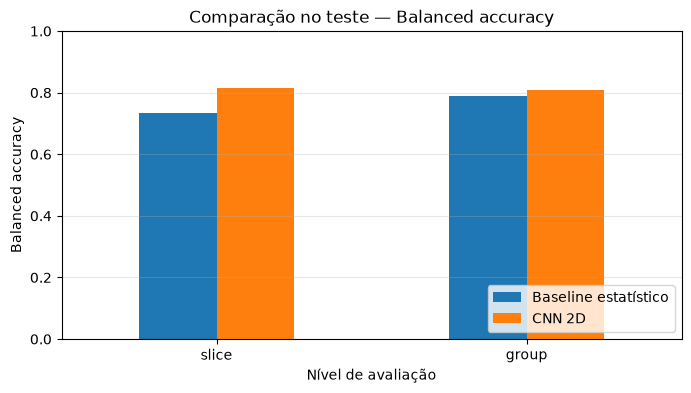

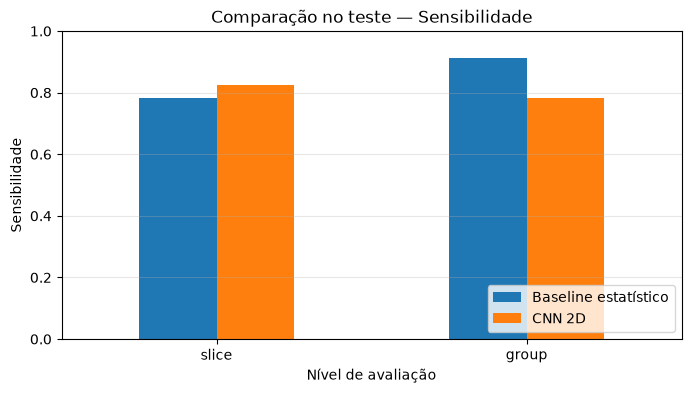

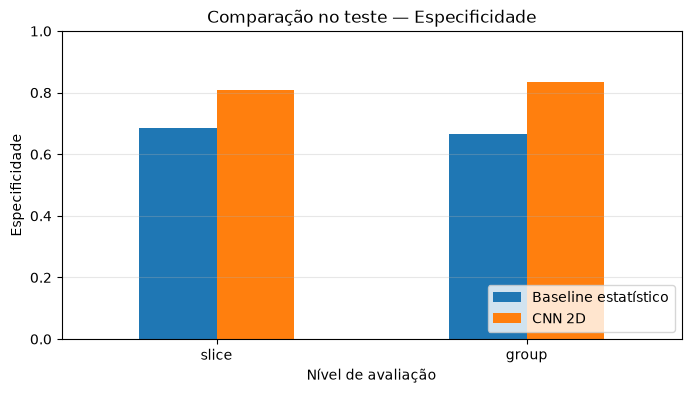

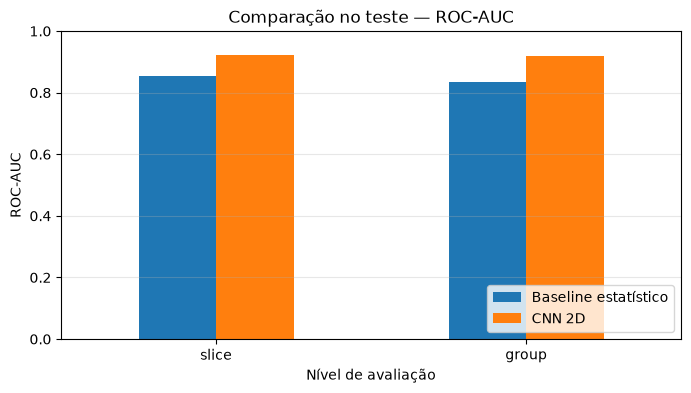

In [7]:
plot_df = comparison.copy()

metrics_to_plot = [
    ("balanced_accuracy", "Balanced accuracy"),
    ("recall_sensitivity", "Sensibilidade"),
    ("specificity", "Especificidade"),
    ("roc_auc", "ROC-AUC"),
]

for metric, title in metrics_to_plot:
    cols = ["level", f"reference_{metric}", f"cnn_{metric}"]
    temp = plot_df[cols].copy()
    temp = temp.rename(
        columns={
            f"reference_{metric}": "Baseline estatístico",
            f"cnn_{metric}": "CNN 2D",
        }
    )
    temp = temp.set_index("level")

    ax = temp.plot(kind="bar", figsize=(8, 4))
    ax.set_title(f"Comparação no teste — {title}")
    ax.set_xlabel("Nível de avaliação")
    ax.set_ylabel(title)
    ax.set_ylim(0, 1)
    ax.legend(loc="lower right")
    plt.xticks(rotation=0)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

## 6. Matrizes de confusão

As matrizes abaixo ajudam a visualizar os erros no teste.

A classe positiva é `Hepatic_Steatosis`.

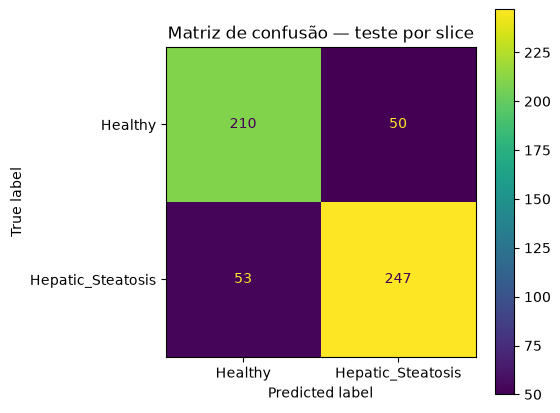

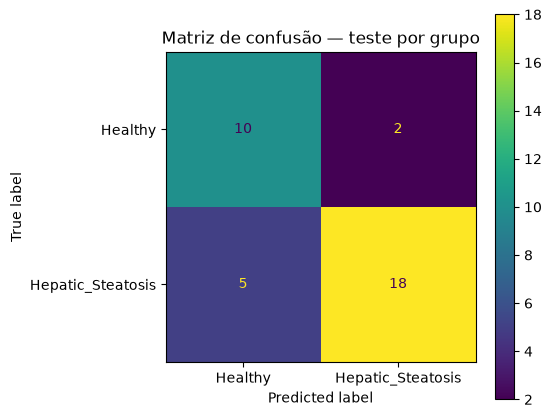

In [8]:
def plot_confusion_from_predictions(df, title):
    y_true = df["label"]
    y_pred = df["pred_label"]

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Healthy", "Hepatic_Steatosis"],
    )

    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, values_format="d")
    ax.set_title(title)
    plt.show()

plot_confusion_from_predictions(
    test_slice_predictions,
    "Matriz de confusão — teste por slice",
)

plot_confusion_from_predictions(
    test_group_predictions,
    "Matriz de confusão — teste por grupo",
)

## 7. Análise dos erros por grupo

Abaixo, listamos os grupos classificados incorretamente no teste.

Esta análise é importante para a próxima etapa: interpretação visual e Grad-CAM.

In [9]:
errors_group = test_group_predictions[
    test_group_predictions["label"] != test_group_predictions["pred_label"]
].copy()

if errors_group.empty:
    print("Nenhum erro no nível de grupo.")
else:
    display(
        errors_group[
            [
                "split",
                "inferred_group_id",
                "label",
                "pred_label",
                "prob_positive",
                "n_slices",
            ]
        ].sort_values("prob_positive").round(4)
    )

,split,inferred_group_id,label,pred_label,prob_positive,n_slices
19,test,207-img-00043,1,0,0.1164,12
23,test,231-img-00019,1,0,0.1776,12
31,test,72-img-00032,1,0,0.3049,16
9,test,160-img-00003,1,0,0.4948,10
13,test,183-img-00023,1,0,0.4956,13
33,test,96-img-00049,0,1,0.6065,18
1,test,114-img-00064,0,1,0.8059,24


## 8. Interpretação crítica

Resultado observado no teste por grupo:

- a CNN apresentou desempenho acima do acaso;
- a CNN melhorou a especificidade e o ROC-AUC em relação ao baseline estatístico;
- a CNN perdeu sensibilidade em relação ao baseline estatístico;
- a melhora de balanced accuracy por grupo foi pequena.

Portanto, a CNN 2D deve ser interpretada como baseline visual inicial, não como solução diagnóstica definitiva.

## Pontos de atenção

Como o baseline estatístico já apresentou desempenho relevante usando apenas estatísticas globais de intensidade, a CNN pode estar capturando uma combinação de:

- padrão anatômico;
- diferença global de intensidade;
- textura;
- contraste;
- compressão JPEG;
- artefatos de exportação.

A próxima etapa deve incluir análise visual dos erros e interpretabilidade, por exemplo com Grad-CAM.

## 9. Próximos passos

Recomendações para a continuação do projeto:

1. documentar formalmente o baseline CNN;
2. gerar exemplos visuais de falsos positivos e falsos negativos;
3. implementar Grad-CAM;
4. comparar mapas de ativação com regiões hepáticas;
5. avaliar estabilidade dos resultados;
6. evitar qualquer conclusão clínica forte sem validação externa e revisão especializada.